# <p style="text-align:center;">Check the quality of the data from UNARETI</p>

In [1]:
from google.cloud import bigquery
from google.cloud import storage
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
import matplotlib.pyplot as plt
from decimal import *
from calendar import monthrange, month_abbr
import cartopy as ctp
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.io import shapereader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import io
import pygrib
import math
import netCDF4
import pytz

## Attempt to load Moloch data from GCS

In [2]:
# def download_blob_into_memory(bucket_name, blob_name):
#     """Downloads a blob into memory."""
   
#     storage_client = storage.Client()

#     bucket = storage_client.bucket(bucket_name)

#     # Construct a client side representation of a blob.
#     # Note `Bucket.blob` differs from `Bucket.get_blob` as it doesn't retrieve
#     # any content from Google Cloud Storage. As we don't need additional data,
#     # using `Bucket.blob` is preferred here.
#     blob = bucket.blob(blob_name)
#     contents = blob.download_as_bytes()

#     print(
#         "Downloaded storage object {} from bucket {} as the following bytes object: {}.".format(
#             blob_name, bucket_name, contents
#         )
#     )

#     return contents

# def download_blob_to_stream(bucket_name, source_blob_name, file_obj):
#     """Downloads a blob to a stream or other file-like object."""

#     # The ID of your GCS bucket
#     # bucket_name = "your-bucket-name"

#     # The ID of your GCS object (blob)
#     # source_blob_name = "storage-object-name"

#     # The stream or file (file-like object) to which the blob will be written
#     # import io
#     # file_obj = io.BytesIO()

#     storage_client = storage.Client()

#     bucket = storage_client.bucket(bucket_name)

#     # Construct a client-side representation of a blob.
#     # Note `Bucket.blob` differs from `Bucket.get_blob` in that it doesn't
#     # retrieve metadata from Google Cloud Storage. As we don't use metadata in
#     # this example, using `Bucket.blob` is preferred here.
#     blob = bucket.blob(source_blob_name)
#     blob.download_to_file(file_obj)

#     print(f"Downloaded blob {source_blob_name} to file-like object.")

#     return file_obj
#     # Before reading from file_obj, remember to rewind with file_obj.seek(0).

In [3]:
# # The ID of your GCS bucket
# bucket_name = "a2a-dpgt-p-buk-euwe4-arpa-liguria"

# # The ID of your GCS object
# source_blob_name = 'GRIB2/2019/06/molita15sfc_2019060100.grib2'
# #
# obj=download_blob_into_memory(bucket_name, source_blob_name)

In [4]:
# with pygrib.fromstring(obj) as grbs: # extract the data
#     for grb in grbs:
#         data, _, lons =grb.data(lat1,lat2,lon1,lon2)
#         print(np.shape(data))



Sample data

In [284]:
def get_moloch_one(fname):

    dataset_data=np.array([])

    # take points around Milano
    min_lat, max_lat=  45.12, 45.74
    min_lon, max_lon= 9.06, 10.30

    with pygrib.open(fname) as grbs: # extract the data
        for grb in grbs:
            if grb.shortName=='2t': # 2m temperature
                data, lats, lons=grb.data(min_lat, max_lat, min_lon, max_lon)
                
                #print(grb) # display the info of each message
                #print(f"{grb.name}_{grb.level}")
        print(np.shape(data), np.shape(lons), np.shape(lats))

        #print(grbs[1].keys()) # display the available keys

    return data, lats, lons
                


In [285]:
file='GRIB2_2023_06_molita15sfc_2023060100.grib2'
data_moloch, lats_moloch, lons_moloch=get_moloch_one(file)


(2730,) (2730,) (2730,)


In [286]:
def plot_moloch_grid(lats_moloch, lons_moloch):
    
    # take points around Milano
    min_lat, max_lat=  45.00, 45.8
    min_lon, max_lon= 9.0, 10.5

    request = cimgt.OSM() # request background

    fig, ax = plt.subplots(1,1, figsize=(9,9), sharex=True, sharey=True, subplot_kw={'projection':request.crs}, layout='compressed')

    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    ax.add_image(request, 10)

    ax.scatter(lons_moloch, lats_moloch, marker='o', s=2, color='k', transform=ccrs.PlateCarree())

    plt.show()

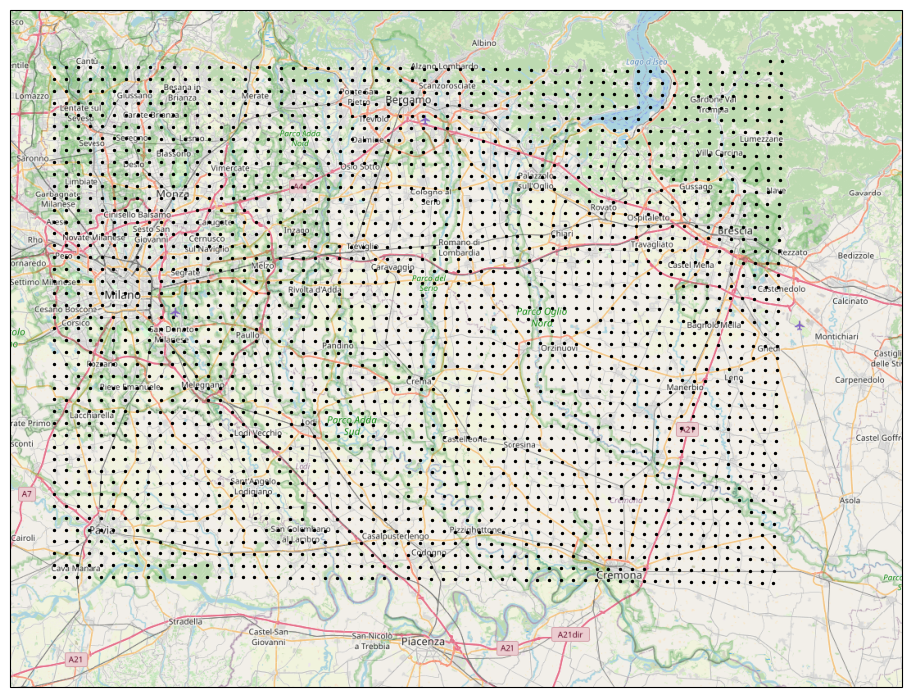

In [287]:
plot_moloch_grid(lats_moloch, lons_moloch)

## Request ECOP data, Moloch data and Observation from Mistral from the DP

In [ ]:
def points_with_observations_and_historical_data_around_milan():
    """
    gives the list of Meteomatics gridpoints (from the anagraphical forecast table) that have a univoque station associated, and for which we have the historic of the IFS forecasts.
    In the dataset:
    ID -> ID of the IFS gridpoint
    ID_CONSUNTIVO -> ID of the univoque station
    LAT, LON -> coordinates of the points
    LAT_METEOMATICS, LON_METEOMATICS -> coordinates of the point given for which the data have been given by Meteomatics
    MIN_LAT_MOLOCH, MIN_LON_MOLOCH -> coordinates of the closest Moloch gridpoint 
    """

    # take points around Milano
    min_lat, max_lat=  45.12, 45.70
    min_lon, max_lon= 9.06, 10.23
    #min_lat, max_lat= 30, 50
    #min_lon, max_lon= 0, 20

    # define the client for the queries
    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)
    
    # query
    query = """
        SELECT ANA.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_FCST` ANA
        WHERE ANA.LAT=(SELECT DISTINCT FCST.LAT, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ECMWF_IFS_METEOMATICS` FCST
            WHERE ANA.LAT=FCST.LAT AND ANA.LON=FCST.LON AND FCST.TRADE_DATE < "2023-01-01T00:00:00"
            )
        AND ANA.LON=(SELECT DISTINCT FCST.LON, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ECMWF_IFS_METEOMATICS` FCST
            WHERE ANA.LAT=FCST.LAT AND ANA.LON=FCST.LON AND FCST.TRADE_DATE < "2023-01-01T00:00:00"
            ) 
        AND ANA.ID_CONSUNTIVO=(SELECT DISTINCT OBS.ID_CONSUNTIVO, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_OBS` OBS
            WHERE ANA.ID_CONSUNTIVO=OBS.ID_CONSUNTIVO AND OBS.STORICO='DS' 
            )
        AND ANA.LAT BETWEEN @min_lat AND @max_lat
        AND ANA.LON BETWEEN @min_lon AND @max_lon

        ORDER BY ANA.ID;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("min_lat", "FLOAT", min_lat),
            bigquery.ScalarQueryParameter("max_lat", "FLOAT", max_lat),
            bigquery.ScalarQueryParameter("min_lon", "FLOAT", min_lon),
            bigquery.ScalarQueryParameter("max_lon", "FLOAT", max_lon),
            ]
        )

    result = client.query(query, job_config=job_config)

    # save the result in a pandas dataset
    dataset = result.to_dataframe(create_bqstorage_client=False).astype({'LAT':float, 'LON':float})
    dataset=dataset.set_index('ID')

    return dataset
    

In [4]:
gridpoints=points_with_observations_and_historical_data_around_milan()
print(gridpoints)

        ID_PAST  ID_CONSUNTIVO        ASSET_ID  \
ID                                               
900370     <NA>         501173  GRIGLIATO_1648   
900372     <NA>         503416  GRIGLIATO_1648   
900441     <NA>         501061  GRIGLIATO_1648   
900474     <NA>         503399  GRIGLIATO_1648   
901979     <NA>         503462  GRIGLIATO_1648   
901981     <NA>         501199  GRIGLIATO_1648   
902004     <NA>         501025             IBM   
902008     <NA>         501042             IBM   
902066     <NA>         501042             IBM   
902071     <NA>         501188             IBM   
902075     <NA>         501177             IBM   
902078     <NA>         501173             IBM   
902079     <NA>         501177             IBM   
902113     <NA>         501042             IBM   

                           ASSET_ID_WTG                         OLD_NAME  \
ID                                                                         
900370  GRIGLIATO_1648_PUNTI_ITALY_1024  Gligli

In [6]:
# get lists of lats and lons of the gridpoints
milan_gridpoints_coordinates=[(lat, lon) for lat, lon in zip(gridpoints['LAT'], gridpoints['LON'])]
print(milan_gridpoints_coordinates) # all different
print(len(milan_gridpoints_coordinates))

[(45.48769, 9.27391), (45.48769, 9.60629), (45.25419, 9.93866), (45.13708, 9.93866), (45.60408, 9.27391), (45.60408, 9.60629), (45.67721, 9.66647), (45.51681, 10.21226), (45.51694, 10.21268), (45.58505, 9.26917), (45.46232, 9.19735), (45.50657, 9.26979), (45.46216, 9.19692), (45.51132, 10.20826)]
14


In [5]:
def query_ecop_ponctual(list_coordinates, var, list_forecast_date):
    """
    get the timeseries of the ecop forecast for the list of points 
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    query = """
        SELECT FCST.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ECMWF_IFS_METEOMATICS` FCST
        WHERE FCST.LAT IN UNNEST(@list_lat)
            AND FCST.LON IN UNNEST(@list_lon)
            AND FCST.COD_DATA_TYPE= @var
            AND FCST.TRADE_DATE in UNNEST(@forecast_dates)
        ORDER BY FCST.VALID_DATE;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_lat", "FLOAT", [lat for lat,_ in list_coordinates]),
            bigquery.ArrayQueryParameter("list_lon", "FLOAT", [lon for _,lon in list_coordinates]),
            bigquery.ArrayQueryParameter("forecast_dates", "DATETIME", list_forecast_date),
            bigquery.ScalarQueryParameter("var", "STRING", var),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False)
    dataset = dataset.astype({'LAT':float, 'LON':float, 'VALUE':float})


    # convert the dates in datetime format and timezone aware
    dataset['VALID_DATE'] = dataset['VALID_DATE'].astype('datetime64[ns]').dt.tz_localize('UTC')
    dataset['TRADE_DATE'] = dataset['TRADE_DATE'].astype('datetime64[ns]').dt.tz_localize('UTC')

    return dataset

In [292]:
forecast_ecop= query_ecop_ponctual(list_coordinates=milan_gridpoints_coordinates, var='T_2M_C', list_forecast_date=['2023-12-10T00:00:00'])
print(forecast_ecop)

                                      FLOW_ID   FLOW_DATE      FLOW_EXEC  \
0      METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
1      METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
2      METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
3      METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
4      METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
...                                       ...         ...            ...   
71731  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
71732  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
71733  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
71734  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
71735  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   

      PUBLICATION_DT FILE_NAME       LAT       LON                VALID_DATE  \
0      

In [293]:
def query_mistral_ponctual(list_station_id, var, dates):
    """
    get the timeseries of the observations for the list of stations and dates
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    # dates in ECOP are in UTC, but CET for Mistral
    dates_CET=[(dt.datetime.strptime(date, '%Y-%m-%dT%H:%M:%S')+dt.timedelta(hours=1)).strftime('%Y-%m-%dT%H:%M:%S') for date in dates]

    # get the list of names corresponding to the station ID (in anagrafe, it's the old name)
    query1="""SELECT DISTINCT ANA.OLD_STATION_NAME, ANA.ID_CONSUNTIVO FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_OBS` ANA WHERE ANA.ID_CONSUNTIVO IN UNNEST(@list_station_id)"""
    job_config1 = bigquery.QueryJobConfig(query_parameters=[bigquery.ArrayQueryParameter("list_station_id", "FLOAT", list_station_id)])
    result1 = client.query(query1, job_config=job_config1)
    dataset1 = result1.to_dataframe(create_bqstorage_client=False)
    list_station_name=[n for n in dataset1['OLD_STATION_NAME']]

    #query2="""SELECT DISTINCT OBS.STATION_NAME FROM `a2a-dataplatformgt-dwh-prd.L2.F_OBSERVATION_DATA_MISTRAL` OBS WHERE OBS.STATION_NAME IN UNNEST(@stname) """
    #job_config2 = bigquery.QueryJobConfig(query_parameters=[ bigquery.ArrayQueryParameter("stname", "STRING", [s for s in dataset1['OLD_STATION_NAME']])])
    #result2 = client.query(query2, job_config=job_config2)
    #dataset2 = result2.to_dataframe(create_bqstorage_client=False)
    #print(dataset2)

    # query the observations 
    query= """ SELECT OBS.REF_TIME, OBS.LATITUDE, OBS.LONGITUDE, OBS.STATION_NAME, OBS.VALUE
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_OBSERVATION_DATA_MISTRAL` OBS
        WHERE OBS.STATION_NAME IN UNNEST(@list_station_name_)
            AND OBS.PRODUCT= @var_
            AND OBS.REF_TIME IN UNNEST(ARRAY(SELECT PARSE_DATETIME("%Y-%m-%dT%H:%M:%S", d) FROM UNNEST(@dates_) AS d))
        ORDER BY OBS.REF_TIME; """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_station_name_", "STRING", list_station_name),
            bigquery.ArrayQueryParameter("dates_", "STRING", dates_CET),
            bigquery.ScalarQueryParameter("var_", "STRING", var),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False).astype({'LATITUDE':float, 'LONGITUDE':float, 'VALUE':float})

    # set the timezone of REF_TIME as CET and convert to UTC
    dataset['REF_TIME'] = dataset['REF_TIME'].astype('datetime64[ns]').dt.tz_localize('CET').dt.tz_convert('UTC') 

    return dataset1, dataset

In [294]:
list_stations_id_milan=[id for id in gridpoints['ID_CONSUNTIVO']]
print(list_stations_id_milan)

[502484, 502527, 502431, 502222, 502094, 502060, 501982, 503642, 501443, 503759, 503838, 503781, 503700, 501173, 503416, 503993, 502826, 503940, 503459, 503852, 501061, 502969, 501788, 501855, 501864, 503399, 503375, 502846, 501766, 501568, 501715, 503213, 502982, 501794, 503139, 503894, 503127, 501667, 501726, 501598, 501569, 503218, 504285, 504923, 501802, 501654, 501813, 501557, 500914, 500905, 500964, 504411, 504165, 504224, 500876, 500814, 500860, 504510, 504373, 504498, 503195, 503216, 500030, 500201, 501876, 500986, 500897, 504357, 503193, 504537, 501856, 503715, 500904, 500932, 500844, 500922, 504549, 504280, 500976, 504571, 503533, 500819, 500966, 504229, 501461, 501460, 502716, 501432, 502746, 501381, 502695, 501419, 501467, 500573, 500717, 500664, 500740, 500661, 500618, 500677, 500596, 500192, 500734, 500571, 502931, 504638, 500610, 500667, 503662, 500577, 503237, 500686, 503498, 503494, 503092, 500376, 500365, 501926, 503636, 500506, 500081, 502158, 500465, 500383, 503556,

In [295]:
dates_from_forecast = list(set([d.strftime("%Y-%m-%dT%H:%M:%S") for d in forecast_ecop['VALID_DATE']]))
dates_from_forecast.sort()
print(dates_from_forecast)
print(len(dates_from_forecast)) # in UTC

['2023-12-10T04:00:00', '2023-12-10T05:00:00', '2023-12-10T06:00:00', '2023-12-10T07:00:00', '2023-12-10T08:00:00', '2023-12-10T09:00:00', '2023-12-10T10:00:00', '2023-12-10T11:00:00', '2023-12-10T12:00:00', '2023-12-10T13:00:00', '2023-12-10T14:00:00', '2023-12-10T15:00:00', '2023-12-10T16:00:00', '2023-12-10T17:00:00', '2023-12-10T18:00:00', '2023-12-10T19:00:00', '2023-12-10T20:00:00', '2023-12-10T21:00:00', '2023-12-10T22:00:00', '2023-12-10T23:00:00', '2023-12-11T00:00:00', '2023-12-11T01:00:00', '2023-12-11T02:00:00', '2023-12-11T03:00:00', '2023-12-11T04:00:00', '2023-12-11T05:00:00', '2023-12-11T06:00:00', '2023-12-11T07:00:00', '2023-12-11T08:00:00', '2023-12-11T09:00:00', '2023-12-11T10:00:00', '2023-12-11T11:00:00', '2023-12-11T12:00:00', '2023-12-11T13:00:00', '2023-12-11T14:00:00', '2023-12-11T15:00:00', '2023-12-11T16:00:00', '2023-12-11T17:00:00', '2023-12-11T18:00:00', '2023-12-11T19:00:00', '2023-12-11T20:00:00', '2023-12-11T21:00:00', '2023-12-11T22:00:00', '2023-12-1

In [296]:
stations_and_id, observations_milan = query_mistral_ponctual(list_station_id=list_stations_id_milan, var='TEMPERATURE/DRY-BULB TEMPERATURE', dates=dates_from_forecast)
print(observations_milan) 


                      REF_TIME  LATITUDE  LONGITUDE  \
0    2023-12-10 04:00:00+00:00  39.50000   16.40278   
1    2023-12-10 04:00:00+00:00  41.64389   12.91500   
2    2023-12-10 04:00:00+00:00  40.79117   17.11767   
3    2023-12-10 04:00:00+00:00  46.51778   10.59556   
4    2023-12-10 04:00:00+00:00  44.29792   10.42750   
...                        ...       ...        ...   
8907 2023-12-12 04:00:00+00:00  46.46511   10.37274   
8908 2023-12-12 04:00:00+00:00  40.50056   15.76111   
8909 2023-12-12 04:00:00+00:00  46.40453   11.61362   
8910 2023-12-12 04:00:00+00:00  46.36053    9.31999   
8911 2023-12-12 04:00:00+00:00  39.48589    9.26578   

                          STATION_NAME   VALUE  
0                                 Acri  279.75  
1                                 Cori  283.65  
2                                 Noci  278.35  
3                                Solda  270.75  
4                               Febbio  276.65  
...                                ...     ..

In [ ]:
def get_anagrafe():

    # associate stations and their lat, lon to the closest gridpoint lat, lon
    anagrafe = pd.DataFrame(index=['E'+str(n) for n in range(len(milan_gridpoints_coordinates))], columns=['station_name', 'station_id', 'lat_station', 'lon_station', 'lat_gridpoint', 'lon_gridpoint'])

    for i, stid in enumerate(list_stations_id_milan): # some of them are duplicates, bc station is associated to different gridpoints
        anagrafe.loc['E'+str(i), 'station_id']=stid
        
        # station name
        sliced=stations_and_id[stations_and_id['ID_CONSUNTIVO']==stid]
        stname=sliced['OLD_STATION_NAME'].values[0]
        anagrafe.loc['E'+str(i), 'station_name']=stname
        
        # station coords
        sliced=observations_milan[observations_milan['STATION_NAME']==stname]
        try:
            lat=sliced.iloc[0]['LATITUDE']
            anagrafe.loc['E'+str(i), 'lat_station']= lat
        except:
            pass
        try:
            lon=sliced.iloc[0]['LONGITUDE']
            anagrafe.loc['E'+str(i), 'lon_station']= lon
        except:
            pass

        # gridpoint coords (careful to take a new one)
        sliced=gridpoints[gridpoints['ID_CONSUNTIVO']==stid]
        sliced=sliced.reset_index()
        lat_grid, lon_grid=sliced.iloc[0]['LAT'], sliced.iloc[0]['LON']
        c=1
        while ((lat_grid,lon_grid) in ((la, lo) for la, lo in zip(anagrafe['lat_gridpoint'].to_list(), anagrafe['lon_gridpoint'].to_list()))): # if already in dataframe
            lat_grid, lon_grid=sliced.loc[c,'LAT'], sliced.loc[c,'LON']
            c+=1
        anagrafe.loc['E'+str(i), 'lat_gridpoint']=lat_grid
        anagrafe.loc['E'+str(i), 'lon_gridpoint']=lon_grid

    anagrafe=anagrafe.astype({'station_name':'str', 'station_id':'int', 'lat_station':'float', 'lon_station':'float', 'lat_gridpoint':'float', 'lon_gridpoint':'float'})

    return anagrafe


In [298]:
anagrafe=get_anagrafe()
anagrafe=anagrafe[anagrafe['station_name']!='Monza v.Monte Generoso'].reset_index(drop=True) # remove v. Monte Generoso

anagrafe= anagrafe.sort_values('station_name')
anagrafe['id']=['E'+str(n) for n in range(len(anagrafe.index.values))]
anagrafe.set_index('id', inplace=True)
anagrafe.index.name = None
print(anagrafe)

KeyError: 2

## Find Moloch gridpoints close to stations

In [ ]:
def moloch_anagrafe():
    """
    creates an anagrafe for the 2 closest gridpoints of Moloch to the stations
    """

    anagrafe_moloch=pd.DataFrame(index=['M'+str(n) for n in range(18)], columns=['station_name', 'station_id', 'lat_station', 'lon_station', 'lat_moloch', 'lon_moloch'])

    list_station = sorted(list(set(anagrafe.loc[j, 'station_name'] for j in anagrafe.index)))

    k=0                
    for station in list_station:

        lat_station, lon_station= math.radians(anagrafe['lat_station'][anagrafe['station_name']==station].values[0]), math.radians(anagrafe['lon_station'][anagrafe['station_name']==station].values[0])
        
        # create an array distance, as the grid is not aligned on lat, lon, using Haversine formula
        a = [ math.sin((math.radians(lat)-lat_station)/2)**2 + math.cos(math.radians(lat))*math.cos(lat_station)*math.sin((math.radians(lon)-lon_station)/2)**2 for lat, lon in zip(lats_moloch, lons_moloch)]
        c = [ 2*math.atan2(math.sqrt(aa), math.sqrt(1-aa)) for aa in a]
        R = 6371000 # earth's radius in km
        distance= [R*cc for cc in c]

        # find the 3 closest points
        distance_sorted=sorted(distance)[:2]
        for point in distance_sorted:
            where_is = np.nanargmin([abs(d-point) for d in distance])
            lat_moloch, lon_moloch = lats_moloch[where_is], lons_moloch[where_is]
            
            # put in the new anagrafe
            anagrafe_moloch.loc['M'+str(k), 'station_name']=station
            anagrafe_moloch.loc['M'+str(k), 'station_id']=anagrafe['station_id'][anagrafe['station_name']==station].values[0]
            anagrafe_moloch.loc['M'+str(k), 'lat_station']=anagrafe['lat_station'][anagrafe['station_name']==station].values[0]
            anagrafe_moloch.loc['M'+str(k), 'lon_station']=anagrafe['lon_station'][anagrafe['station_name']==station].values[0]
            anagrafe_moloch.loc['M'+str(k), 'lon_moloch']=lon_moloch
            anagrafe_moloch.loc['M'+str(k), 'lat_moloch']=lat_moloch
            k+=1

    return anagrafe_moloch
    

In [ ]:
anagrafe_moloch=moloch_anagrafe()
print(anagrafe_moloch)

                station_name station_id lat_station lon_station lat_moloch  \
M0        Bergamo v.Stezzano     501025    45.66052     9.65877  45.661152   
M1        Bergamo v.Stezzano     501025    45.66052     9.65877  45.661036   
M2         Brescia v.Ziziola     501042    45.51456    10.21846   45.51664   
M3         Brescia v.Ziziola     501042    45.51456    10.21846  45.516432   
M4     Casalbuttano ed Uniti     501061    45.25596     9.96349  45.252928   
M5     Casalbuttano ed Uniti     501061    45.25596     9.96349  45.253092   
M6           Milano Lambrate     501173    45.49678     9.25752  45.494724   
M7           Milano Lambrate     501173    45.49678     9.25752   45.49468   
M8            Milano v.Brera     501177    45.47166     9.18911   45.46684   
M9            Milano v.Brera     501177    45.47166     9.18911   45.48084   
M10  Osio Sotto v.per Levate     501199    45.62056     9.61174  45.619372   
M11  Osio Sotto v.per Levate     501199    45.62056     9.61174 

In [ ]:
def where_are_points():
    """
    plot stations and gridpoints on a map
    """
    # take points around Milano
    #min_lat, max_lat=  45.00, 45.8
    #min_lon, max_lon= 9.0, 10.5
    min_lat, max_lat= 30, 50
    min_lon, max_lon= 0, 20

    request = cimgt.OSM() # request background

    colorz = plt.cm.gist_rainbow(np.linspace(0,1,len(set(anagrafe['station_name'].values))))
    fig, ax = plt.subplots(1,1, figsize=(12,12), sharex=True, sharey=True, subplot_kw={'projection':request.crs}, layout='compressed')

    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    ax.add_image(request, 10)

    nECOP=0
    nMoloch=0
    for i, station in enumerate(sorted(list(set(anagrafe['station_name'].values)))):
        
        for lat, lon in zip(anagrafe['lat_gridpoint'][anagrafe['station_name']==station].values, anagrafe['lon_gridpoint'][anagrafe['station_name']==station].values):
            ax.scatter(lon, lat, s=30, marker='^', color=colorz[i], transform=ccrs.PlateCarree(), edgecolors='k', label='E'+str(nECOP))
            nECOP+=1

        for lat, lon in zip(anagrafe_moloch['lat_moloch'][anagrafe_moloch['station_name']==station].values, anagrafe_moloch['lon_moloch'][anagrafe_moloch['station_name']==station].values):
            ax.scatter(lon, lat, s=30, marker='o', color=colorz[i], transform=ccrs.PlateCarree(), edgecolors='k', label='M'+str(nMoloch))
            nMoloch+=1
        
        ax.scatter(anagrafe['lon_station'][anagrafe['station_name']==station].values[0], anagrafe['lat_station'][anagrafe['station_name']==station].values[0], s=200, marker='*', color=colorz[i], edgecolors='k', transform=ccrs.PlateCarree(), label=station)

    plt.legend(ncols=2, bbox_to_anchor=(1.0, 1.0))
    plt.show()


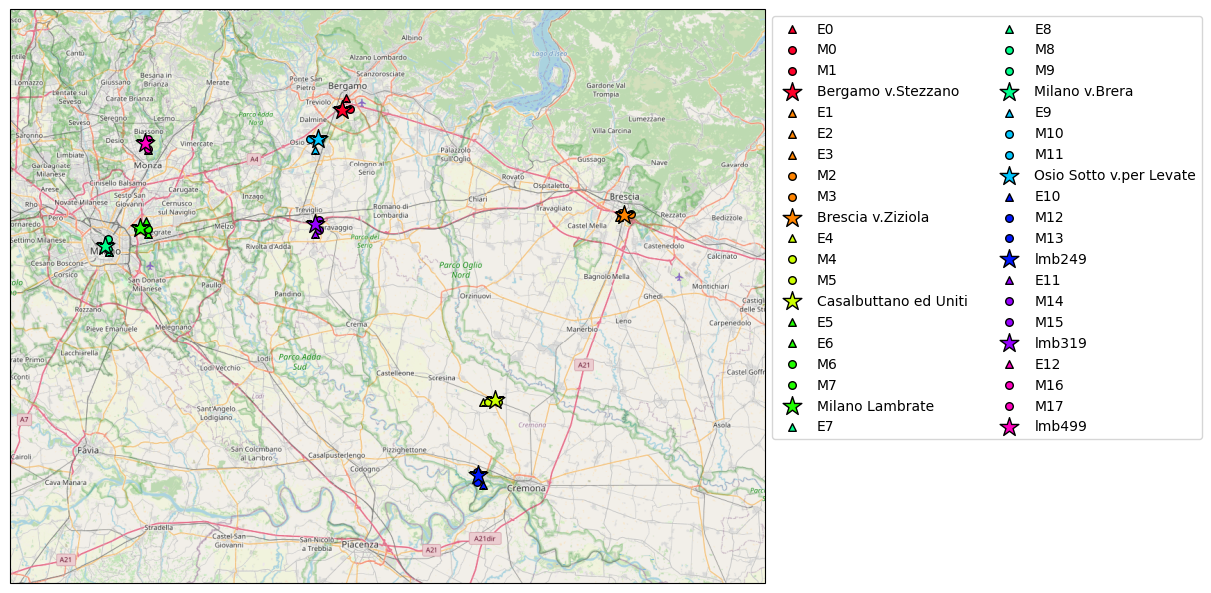

In [ ]:
where_are_points()

## Plot Forecasts ECOP vs .Observations

In [ ]:
def plot_timeseries_one_forecast(timeseries_obs, timeseries_ecop):

    fig, ax = plt.subplots(1,2, figsize=(15,8), sharex=True)

    list_stname=sorted(list(set(anagrafe['station_name'].values)))
    n = len(list_stname)
    
    colorz = plt.cm.gist_rainbow(np.linspace(0,1,n))

    nECOP=0
    for i, station in enumerate(list_stname):

        # plot obs 
        lat_obs, lon_obs = anagrafe['lat_station'][anagrafe['station_name']==station].values[0], anagrafe['lon_station'][anagrafe['station_name']==station].values[0]
        subdata_obs = timeseries_obs[(timeseries_obs['LATITUDE']==lat_obs)]
        subdata_obs=subdata_obs[subdata_obs['LONGITUDE']==lon_obs]
        subdata_obs['REF_TIME'] = subdata_obs['REF_TIME'].dt.strftime('%Y-%m-%dT%H:%M:%S') # recast to string
        strdate_from_ecop=[str(np.datetime_as_string(d,  unit='s')) for d in sorted(list(set(timeseries_ecop['VALID_DATE'].values)))]
        subdata_obs=subdata_obs[subdata_obs['REF_TIME'].isin(strdate_from_ecop)]
        subdata_obs=subdata_obs.set_index('REF_TIME')
        subdata_obs.index = pd.to_datetime(subdata_obs.index)
        xdates_obs=subdata_obs.index.values
        ax[0].plot(xdates_obs, subdata_obs['VALUE']-273.15, color=colorz[i], linewidth=1, linestyle='-', label=station)
        
        # plot forecast
        for lat_forecast, lon_forecast in zip(anagrafe['lat_gridpoint'][anagrafe['station_name']==station].values, anagrafe['lon_gridpoint'][anagrafe['station_name']==station].values):
            subdata_fcst = timeseries_ecop[(timeseries_ecop['LAT']==lat_forecast)]
            subdata_fcst=subdata_fcst[subdata_fcst['LON']==lon_forecast]
            subdata_fcst['VALID_DATE']= pd.to_datetime(subdata_fcst['VALID_DATE'], format="%Y-%m-%d %H:%M:%S")
            subdata_fcst['VALID_DATE'] = subdata_fcst['VALID_DATE'].dt.strftime('%Y-%m-%dT%H:%M:%S') # recast to string
            subdata_fcst= subdata_fcst.set_index('VALID_DATE')
            subdata_fcst.index = pd.to_datetime(subdata_fcst.index)
            xdates_fcst=subdata_fcst.index.values
            ax[0].plot(xdates_fcst, subdata_fcst['VALUE'], color=colorz[i], linewidth=1, linestyle='--')
            
            nECOP+=1

            # plot error
            error=subdata_fcst['VALUE']-subdata_obs['VALUE']+273.15
            ax[1].plot(error, color=colorz[i], linewidth=1, linestyle='-', label='E'+str(nECOP)+  ': {}'.format(station))
    
    ax[1].legend(bbox_to_anchor=(1.0, 1.0))

    # ticks
    #myticks=[xdates_fcst[0], xdates_fcst[8], xdates_fcst[20], xdates_fcst[32], xdates_fcst[44]]
    #ax[0].set_xticks(ticks=myticks, labels=[f.astype(dt.datetime).strftime("%d/%m %H:%M") for f in myticks])
    plt.setp(ax[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.setp(ax[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")


    ax[0].set_title('absolute value')
    ax[1].set_title('error (forecast-obs)')
    
    plt.suptitle('var: {}; trade_date: {}'.format(timeseries_ecop['COD_DATA_TYPE'][0], timeseries_ecop['TRADE_DATE'][0]))
    plt.show()
    
    

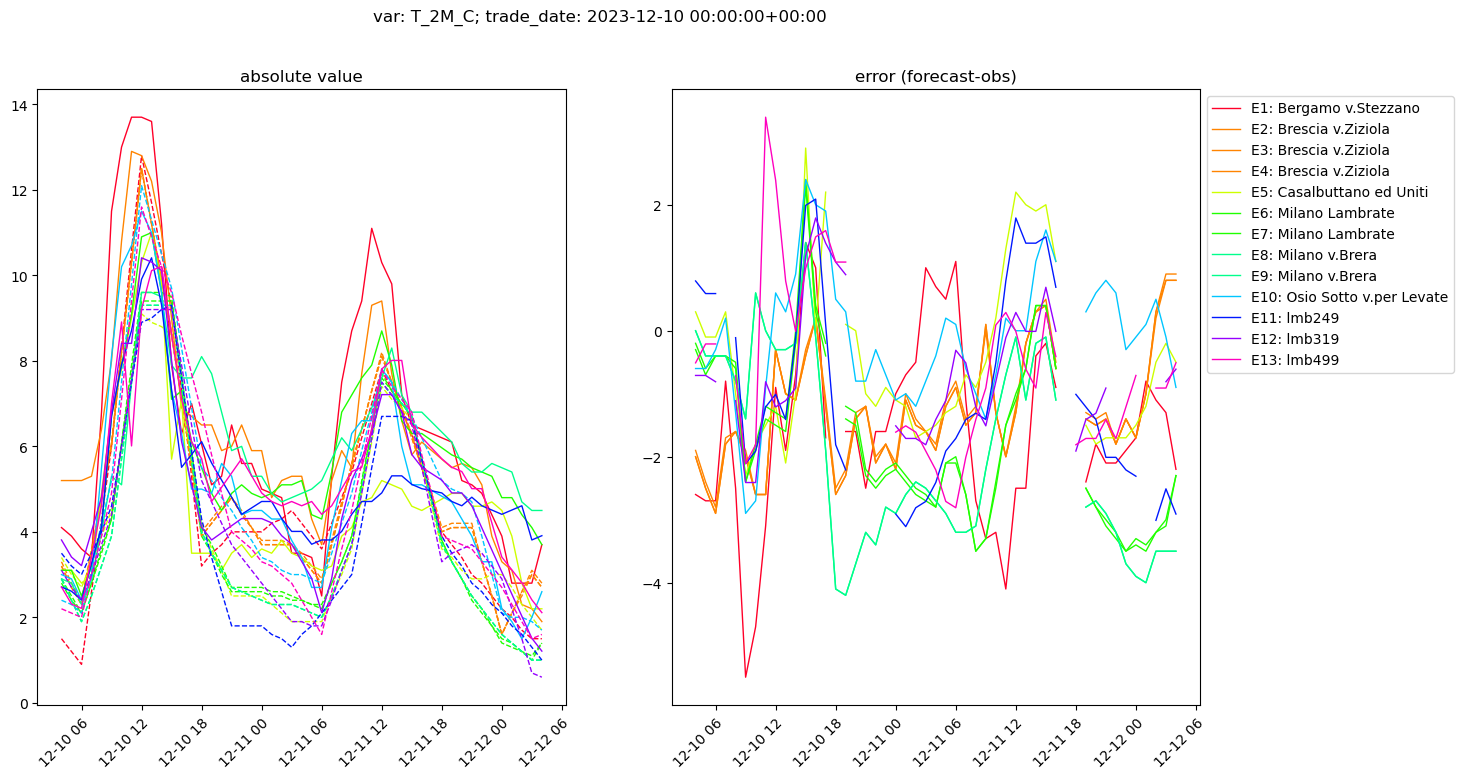

                     REF_TIME  LATITUDE  LONGITUDE             STATION_NAME  \
0   2023-12-10 04:00:00+00:00  45.15187    9.92864                   lmb249   
1   2023-12-10 04:00:00+00:00  45.50219    9.60631                   lmb319   
2   2023-12-10 04:00:00+00:00  45.47166    9.18911           Milano v.Brera   
3   2023-12-10 04:00:00+00:00  45.25596    9.96349    Casalbuttano ed Uniti   
4   2023-12-10 04:00:00+00:00  45.62056    9.61174  Osio Sotto v.per Levate   
..                        ...       ...        ...                      ...   
399 2023-12-12 04:00:00+00:00  45.61395    9.26794                   lmb499   
400 2023-12-12 04:00:00+00:00  45.51456   10.21846        Brescia v.Ziziola   
401 2023-12-12 04:00:00+00:00  45.25596    9.96349    Casalbuttano ed Uniti   
402 2023-12-12 04:00:00+00:00  45.15187    9.92864                   lmb249   
403 2023-12-12 04:00:00+00:00  45.49678    9.25752          Milano Lambrate   

      VALUE  
0    275.86  
1    276.96  
2    276.

In [ ]:
plot_timeseries_one_forecast(observations_milan, forecast_ecop)
print(observations_milan)

In [ ]:
def plot_timeseries_average(list_months, list_years, var):
    """
    plot the average error for the forecast trade dates, dividing per month
    """

    # var equiv
    var_ecop={"TEMPERATURE/DRY-BULB TEMPERATURE":"T_2M_C"}
    
    list_stname=sorted(list(set(anagrafe['station_name'].values)))
    n = len(list_stname)
    
    # figure    
    colorz = plt.cm.gist_rainbow(np.linspace(0,1,n))
    fig, ax =plt.subplots(len(list_months),3, figsize=(14,3*len(list_months)), sharex=True, sharey='col')

    # create a list of trade dates from the monthsm one sublist is one month
    list_trade_dates=[[dt.datetime(year, month, day, 0, 0, 0, 0, pytz.UTC) for year in list_years for day in range(1, monthrange(year, month)[1]+1)] for  month in list_months] 
    list_trade_dates_flat= [d for sublist in list_trade_dates for d in sublist]
    #list_trade_dates = [dt.datetime(2023,12,10,0,0,0), dt.datetime(2023,12,10,0,0,0)]

    hours = [dt.timedelta(hours=n) for n in range(4,53)] # hours elapsed since start of forecast
    average_forecast= pd.DataFrame(index=hours, columns=anagrafe.index.values)
    error_per_hour = pd.DataFrame(index=hours, columns=anagrafe.index.values)
    error_absolute_per_hour = pd.DataFrame(index=hours, columns=anagrafe.index.values)
    
    # query ecop and mistral for all stations, all trade dates
    list_date_str = [date.strftime('%Y-%m-%dT%H:%M:%S') for date in list_trade_dates_flat]
    ecop = query_ecop_ponctual([(lat, lon) for lat, lon in zip(anagrafe['lat_gridpoint'].values, anagrafe['lon_gridpoint'].values)], var=var_ecop[var], list_forecast_date=list_date_str)
    dates_from_ecop = list(set([d.strftime("%Y-%m-%dT%H:%M:%S") for d in ecop['VALID_DATE']]))
    dates_from_ecop.sort()
    _,obs = query_mistral_ponctual(list(anagrafe['station_id'].values), var=var, dates=dates_from_ecop)

    # compute error station per station
    for im, sublist_trade_dates in enumerate(list_trade_dates): # iterate over months

        nMissingForecast=0
        is_there_obs = pd.DataFrame(np.zeros((len(hours), len(anagrafe.index.values))), index=hours, columns=anagrafe.index.values)
   
        for j, station in enumerate(list_stname):

            lon_station, lat_station = anagrafe['lon_station'][anagrafe['station_name']==station].values[0], anagrafe['lat_station'][anagrafe['station_name']==station].values[0]

            for id, lat_forecast, lon_forecast in zip(anagrafe.index[anagrafe['station_name']==station].values, anagrafe['lat_gridpoint'][anagrafe['station_name']==station].values, anagrafe['lon_gridpoint'][anagrafe['station_name']==station].values):
                
                for td in sublist_trade_dates:
                    td_str = td.strftime('%Y-%m-%dT%H:%M:%S')
                    forecast_ecop = ecop.loc[(ecop['LAT'] == lat_forecast) & (ecop['LON'] == lon_forecast) & (ecop['TRADE_DATE'] == td)]  # timeseries for one station, one trade date
                    dates_from_this_forecast = forecast_ecop['VALID_DATE'].to_list()
                    obs_slice = obs.loc[(obs['LATITUDE']==lat_station)&(obs['LONGITUDE']==lon_station)&(obs['REF_TIME'].isin(dates_from_this_forecast))]

                    if np.isnan(forecast_ecop['VALUE']).all(): # no forecast here
                        print('No forecast for', td)
                        nMissingForecast +=1
                        continue

                    # set index
                    obs_slice.set_index('REF_TIME', inplace=True)
                    forecast_ecop.set_index('VALID_DATE', inplace=True)
                    forecast_ecop.index.rename('REF_TIME', inplace=True)

                    # compute error
                    error= forecast_ecop['VALUE']-obs_slice['VALUE']+273.15
                    error.index=(error.index-td)

                    # 1 if there is a data, 0 else
                    is_there_obs[id]= is_there_obs[id].add(np.where(np.isnan(error), 0,1))

                    # add to dataset as element of the mean
                    average_forecast[id]=np.nansum(np.vstack((average_forecast[id].values, forecast_ecop['VALUE'].values)), axis=0)
                    error_per_hour[id]= np.nansum(np.vstack((error_per_hour[id].values, error.values)), axis=0)
                    error_absolute_per_hour[id] = np.nansum(np.vstack((error_absolute_per_hour[id], np.abs(error))), axis=0)

                # divide the error by the number of non nan data
                is_there_obs[id] = is_there_obs[id].replace(0, np.nan)
                average_forecast[id] =average_forecast[id].div(len(list_trade_dates[im])-nMissingForecast) 
                error_per_hour[id] = error_per_hour[id].div(is_there_obs[id])
                error_absolute_per_hour[id] = error_absolute_per_hour[id].div(is_there_obs[id])

        # plot
        for j, station in enumerate(list_stname):
            for id in anagrafe[anagrafe['station_name']==station].index.values:
                ax[im,0].plot(error_per_hour.index.values/(1000000000*3600), average_forecast[id], color=colorz[j], linewidth=1)
                ax[im,1].plot(error_per_hour.index.values/(1000000000*3600), error_per_hour[id], color=colorz[j], linewidth=1)
                ax[im,2].plot(error_per_hour.index.values/(1000000000*3600), error_absolute_per_hour[id], color=colorz[j], linewidth=1, label=str(id)+': '+station)

    ax[0, 2].legend(bbox_to_anchor=(1.0, 1.0))

    ax[0, 0].set_title('Average forecast')
    ax[0, 1].set_title('Average error')
    ax[0, 2].set_title('Absolute error')

    for k, im in enumerate(list_months):
        ax[k, 0].text(5,30.5, '{}'.format(month_abbr[im]))
    

    plt.suptitle('ECOP forecast error over leadtime')

    plt.subplots_adjust(hspace=0)
    plt.show()


    return None

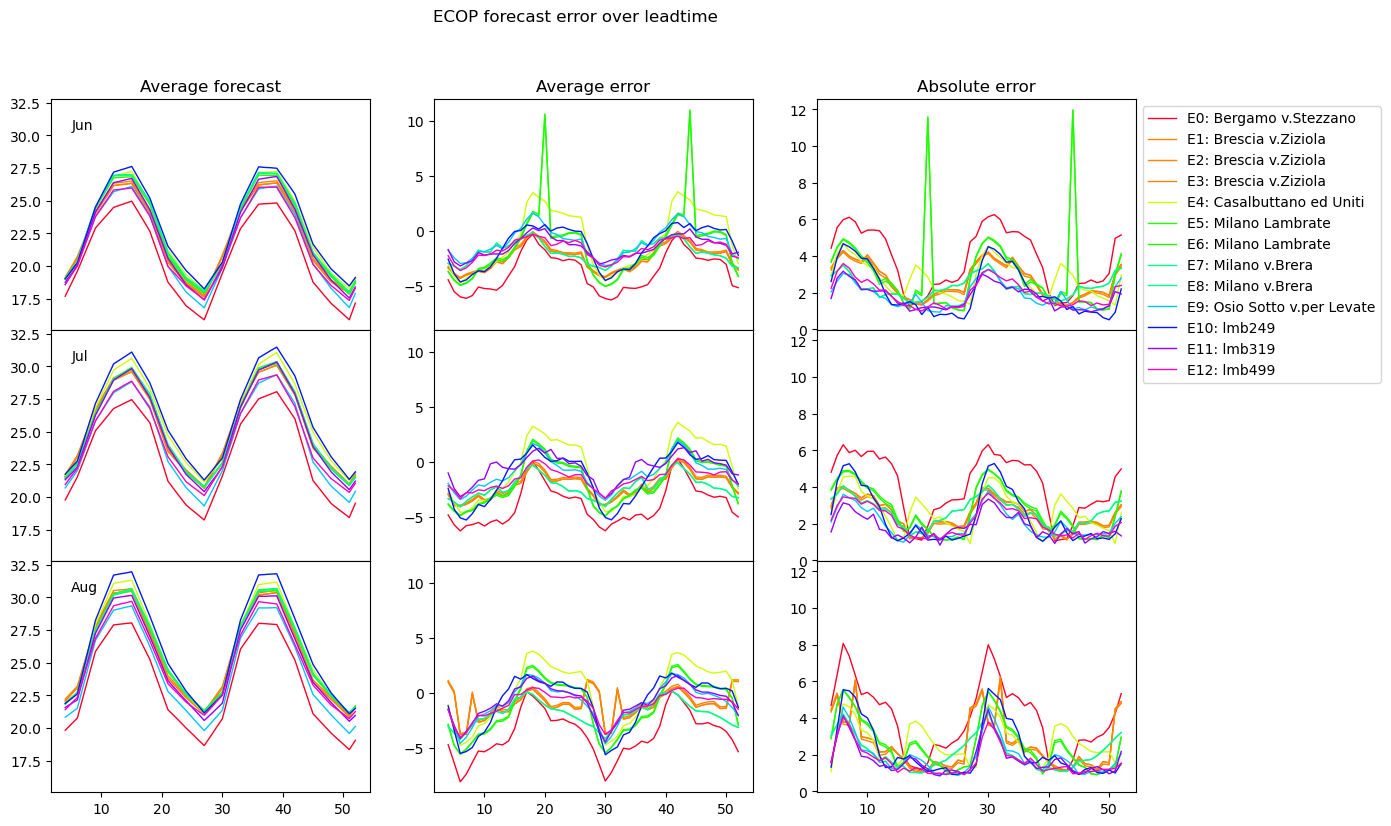

In [ ]:
list_months, list_years = [6,7,8], [2023]
plot_timeseries_average(list_months, list_years, var="TEMPERATURE/DRY-BULB TEMPERATURE")

In [ ]:
def plot_distrib_violin(list_months, list_years, var="TEMPERATURE/DRY-BULB TEMPERATURE"):
    """
    plot violin plots for the monthly distribution of max var temp for each station and gridpoint
    """

    # var equiv
    var_ecop={"TEMPERATURE/DRY-BULB TEMPERATURE":"T_2M_C"}

    list_stname=sorted(list(set(anagrafe['station_name'].values)))
    n = len(list_stname)

    # figure
    colorz = plt.cm.gist_rainbow(np.linspace(0,1,n))
    fig, ax =plt.subplots(len(list_months),2, figsize=(14,3*len(list_months)), sharex=True, sharey=True)

    

    # create a list of trade dates from the monthsm one sublist is one month
    list_trade_dates=[[dt.datetime(year, month, day, 0, 0, 0, 0, pytz.UTC) for year in list_years for day in range(1, monthrange(year, month)[1]+1)] for  month in list_months] 
    list_trade_dates_flat= [d for sublist in list_trade_dates for d in sublist]
    #list_trade_dates = [dt.datetime(2023,12,10,0,0,0), dt.datetime(2023,12,10,0,0,0)]
    
    # query ecop and mistral for all stations, all trade dates
    list_date_str = [date.strftime('%Y-%m-%dT%H:%M:%S') for date in list_trade_dates_flat]
    ecop = query_ecop_ponctual([(lat, lon) for lat, lon in zip(anagrafe['lat_gridpoint'].values, anagrafe['lon_gridpoint'].values)], var=var_ecop[var], list_forecast_date=list_date_str)
    dates_from_ecop = list(set([d.strftime("%Y-%m-%dT%H:%M:%S") for d in ecop['VALID_DATE']]))
    dates_from_ecop.sort()
    _,obs = query_mistral_ponctual(list(anagrafe['station_id'].values), var=var, dates=dates_from_ecop)

    # compute error station per station
    for im, sublist_trade_dates in enumerate(list_trade_dates): # iterate over months

        xlab=[]
        nECOP=0
        for j, station in enumerate(list_stname):
           
            lon_station, lat_station = anagrafe['lon_station'][anagrafe['station_name']==station].values[0], anagrafe['lat_station'][anagrafe['station_name']==station].values[0]

            nECOP_station=0
            for id, lat_forecast, lon_forecast in zip(anagrafe.index[anagrafe['station_name']==station].values, anagrafe['lat_gridpoint'][anagrafe['station_name']==station].values, anagrafe['lon_gridpoint'][anagrafe['station_name']==station].values):
                
                max_ecop_d0=[]
                max_obs_d0=[]
                max_ecop_d1=[]
                max_obs_d1=[]
                
                for td in sublist_trade_dates:
                
                    forecast_ecop_d0 = ecop.loc[(ecop['LAT']==lat_forecast)&(ecop['LON']==lon_forecast)&(ecop['TRADE_DATE']==td)&(ecop['VALID_DATE'].isin([td+dt.timedelta(hours=n) for n in range(24)]))] # timeseries for one station, one trade date, day 0
                    forecast_ecop_d1 = ecop.loc[(ecop['LAT']==lat_forecast)&(ecop['LON']==lon_forecast)&(ecop['TRADE_DATE']==td)&(ecop['VALID_DATE'].isin([td+dt.timedelta(hours=n) for n in range(24,48)]))]
                    dates_from_ecop_d0_forecast = forecast_ecop_d0['VALID_DATE'].to_list()
                    dates_from_ecop_d1_forecast = forecast_ecop_d1['VALID_DATE'].to_list()

                    obs_slice_d0 = obs.loc[(obs['LATITUDE']==lat_station)&(obs['LONGITUDE']==lon_station)&(obs['REF_TIME'].isin(dates_from_ecop_d0_forecast))]
                    obs_slice_d1 = obs.loc[(obs['LATITUDE']==lat_station)&(obs['LONGITUDE']==lon_station)&(obs['REF_TIME'].isin(dates_from_ecop_d1_forecast))]
                    
                    if forecast_ecop_d0['VALUE'].empty|obs_slice_d0['VALUE'].empty|forecast_ecop_d1['VALUE'].empty|obs_slice_d1['VALUE'].empty: # obs or forecast sub dataset is empty
                        continue


                    # add max temp to dataset
                    max_ecop_d0.append(np.nanmax(forecast_ecop_d0['VALUE'].values))
                    max_ecop_d1.append(np.nanmax(forecast_ecop_d1['VALUE'].values))
                    max_obs_d0.append(np.nanmax(obs_slice_d0['VALUE'].values)-273.15)
                    max_obs_d1.append(np.nanmax(obs_slice_d1['VALUE'].values)-273.15)

                # plot ECOP
                pos=j+nECOP+1
                parts_d0=ax[im,0].violinplot(dataset=max_ecop_d0, positions=[pos], showmeans=True, showmedians=False, showextrema=False)
                parts_d1=ax[im,1].violinplot(dataset=max_ecop_d1, positions=[pos], showmeans=True, showmedians=False, showextrema=False)

                for pc in parts_d0['bodies'] + parts_d1['bodies']:
                    pc.set_facecolor(colorz[j])
                    pc.set_alpha(0.7)
                parts_d0['cmeans'].set_color('k')
                parts_d1['cmeans'].set_color('k')
                nECOP_station+=1
                nECOP+=1
            
            # plot obs
            pos=j-nECOP_station+nECOP
            pobs_d0=ax[im,0].violinplot(dataset=max_obs_d0, positions=[pos], showmeans=True, showmedians=False, showextrema=False)
            pobs_d1=ax[im,1].violinplot(dataset=max_obs_d1, positions=[pos], showmeans=True, showmedians=False, showextrema=False)
            
            # labels x-axis
            xlab.append(station)
            for id in anagrafe.index[anagrafe['station_name']==station].values:
                xlab.append(id)
                

            for pc in pobs_d0['bodies'] + pobs_d1['bodies']:
                pc.set_facecolor(colorz[j])
                pc.set_edgecolor('black')
                pc.set_alpha(0.9)
            pobs_d0['cmeans'].set_color('k')
            pobs_d1['cmeans'].set_color('k')
    
    ax[0, 0].set_title('D0')
    ax[0, 1].set_title('D1')

    ax[len(list_months)-1,0].set_xticks([k for k in range(nECOP+n)], labels=xlab, rotation=40,ha='right')
    ax[len(list_months)-1,1].set_xticks([k for k in range(nECOP+n)], labels=xlab, rotation=40,ha='right')

    for k, im in enumerate(list_months):
        ax[k, 0].text(0,40, '{}'.format(month_abbr[im]), backgroundcolor='white')
    

    plt.suptitle('ECOP maximum temperature distribution')

    plt.subplots_adjust(hspace=0, wspace=0)
    plt.show()


    return None
    


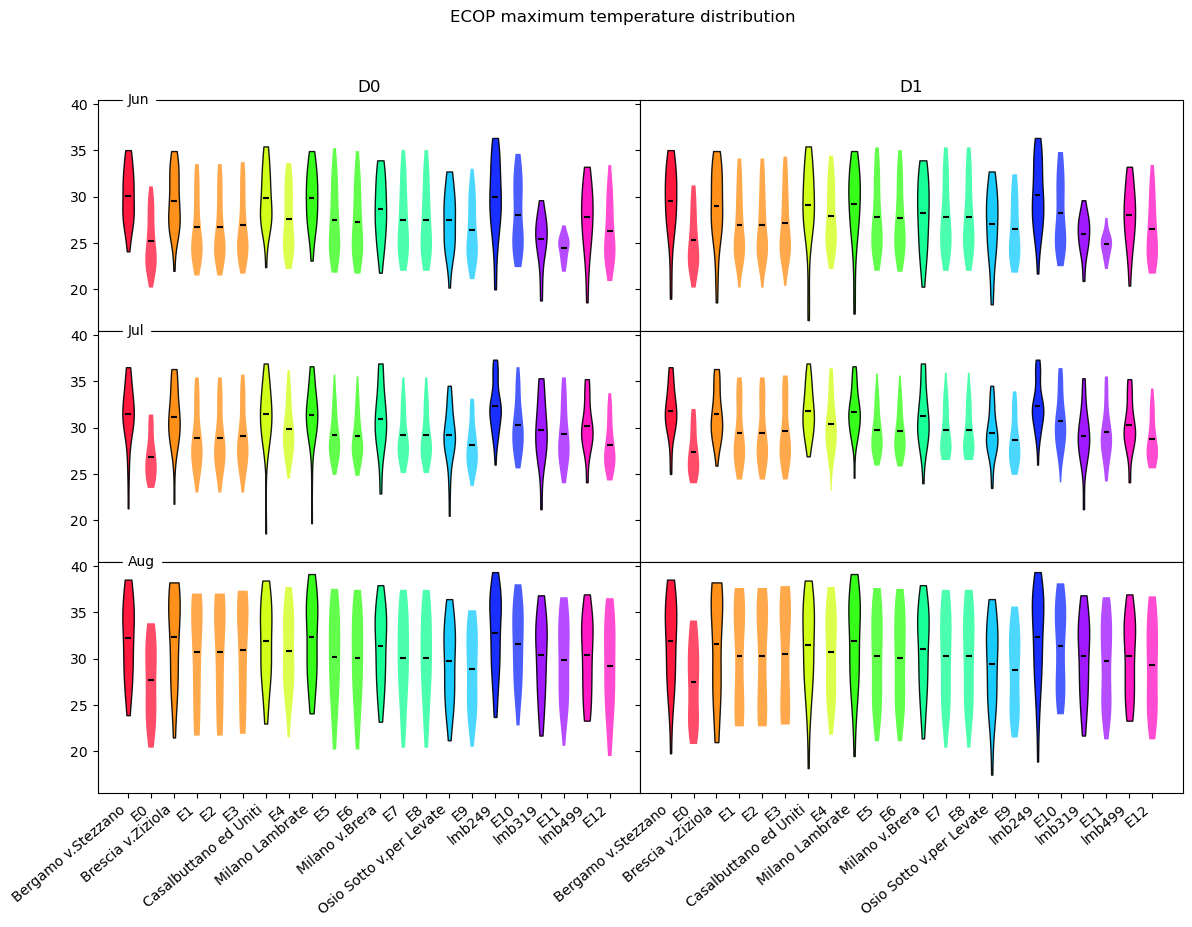

In [ ]:
plot_distrib_violin(list_months, list_years)

In [ ]:
def plot_error_distrib_violin(list_months, list_years, var="TEMPERATURE/DRY-BULB TEMPERATURE"):
    """
    plot violin plots for the monthly distribution of errors between forecast and observation for each station and gridpoint
    """

    # var equiv
    var_ecop = {"TEMPERATURE/DRY-BULB TEMPERATURE": "T_2M_C"}

    list_stname = sorted(list(set(anagrafe['station_name'].values)))
    n = len(list_stname)

    # figure
    colorz = plt.cm.gist_rainbow(np.linspace(0, 1, n))
    fig, ax = plt.subplots(len(list_months), 2, figsize=(10, 12), sharex=True, sharey=True)

    # create a list of trade dates from the months, one sublist is one month
    list_trade_dates = [[dt.datetime(year, month, day, 0, 0, 0, 0, pytz.UTC) for year in list_years for day in range(1, monthrange(year, month)[1] + 1)] for month in list_months]
    list_trade_dates_flat = [d for sublist in list_trade_dates for d in sublist]
    
    # query ecop and mistral for all stations, all trade dates
    list_date_str = [date.strftime('%Y-%m-%dT%H:%M:%S') for date in list_trade_dates_flat]
    ecop = query_ecop_ponctual([(lat, lon) for lat, lon in zip(anagrafe['lat_gridpoint'].values, anagrafe['lon_gridpoint'].values)], var=var_ecop[var], list_forecast_date=list_date_str)
    dates_from_ecop = list(set([d.strftime("%Y-%m-%dT%H:%M:%S") for d in ecop['VALID_DATE']]))
    dates_from_ecop.sort()
    _, obs = query_mistral_ponctual(list(anagrafe['station_id'].values), var=var, dates=dates_from_ecop)

    # compute error station per station
    for im, sublist_trade_dates in enumerate(list_trade_dates):  # iterate over months

        xlab = []
        pos = 0
        for j, station in enumerate(list_stname):
           
            lon_station, lat_station = anagrafe['lon_station'][anagrafe['station_name'] == station].values[0], anagrafe['lat_station'][anagrafe['station_name'] == station].values[0]
            
            for id, lat_forecast, lon_forecast in zip(anagrafe.index[anagrafe['station_name'] == station].values, anagrafe['lat_gridpoint'][anagrafe['station_name'] == station].values, anagrafe['lon_gridpoint'][anagrafe['station_name'] == station].values):
                
                errors_d0 = []
                errors_d1 = []
                
                for td in sublist_trade_dates:
                
                    forecast_ecop_d0 = ecop.loc[(ecop['LAT'] == lat_forecast) & (ecop['LON'] == lon_forecast) & (ecop['TRADE_DATE'] == td) & (ecop['VALID_DATE'].isin([td + dt.timedelta(hours=n) for n in range(24)]))]  # timeseries for one station, one trade date, day 0
                    forecast_ecop_d1 = ecop.loc[(ecop['LAT'] == lat_forecast) & (ecop['LON'] == lon_forecast) & (ecop['TRADE_DATE'] == td) & (ecop['VALID_DATE'].isin([td + dt.timedelta(hours=n) for n in range(24, 48)]))]
                    dates_from_ecop_d0_forecast = forecast_ecop_d0['VALID_DATE'].to_list()
                    dates_from_ecop_d1_forecast = forecast_ecop_d1['VALID_DATE'].to_list()

                    obs_slice_d0 = obs.loc[(obs['LATITUDE'] == lat_station) & (obs['LONGITUDE'] == lon_station) & (obs['REF_TIME'].isin(dates_from_ecop_d0_forecast))]
                    obs_slice_d1 = obs.loc[(obs['LATITUDE'] == lat_station) & (obs['LONGITUDE'] == lon_station) & (obs['REF_TIME'].isin(dates_from_ecop_d1_forecast))]
                    
                    if forecast_ecop_d0['VALUE'].empty or obs_slice_d0['VALUE'].empty or forecast_ecop_d1['VALUE'].empty or obs_slice_d1['VALUE'].empty:  # obs or forecast sub dataset is empty
                        continue

                    # set index for substraction
                    forecast_ecop_d0.set_index('VALID_DATE', inplace=True)
                    forecast_ecop_d0.index.rename('REF_TIME', inplace=True)
                    forecast_ecop_d1.set_index('VALID_DATE', inplace=True)
                    forecast_ecop_d1.index.rename('REF_TIME', inplace=True)

                    obs_slice_d0.set_index('REF_TIME', inplace=True)
                    obs_slice_d1.set_index('REF_TIME', inplace=True)

                    # compute error for max value
                    max_forecast_d0 = forecast_ecop_d0['VALUE'].max()
                    max_obs_d0 = obs_slice_d0['VALUE'].max()
                    max_forecast_d1 = forecast_ecop_d1['VALUE'].max()
                    max_obs_d1 = obs_slice_d1['VALUE'].max()

                    error_d0 = max_forecast_d0 - max_obs_d0 + 273.15
                    error_d1 = max_forecast_d1 - max_obs_d1 + 273.15

                    errors_d0.append(error_d0)
                    errors_d1.append(error_d1)

                # plot errors
                parts_d0 = ax[im, 0].boxplot(errors_d0, positions=[pos], patch_artist=True, boxprops=dict(facecolor=colorz[j], color=colorz[j]), medianprops=dict(color='k'))
                parts_d1 = ax[im, 1].boxplot(errors_d1, positions=[pos], patch_artist=True, boxprops=dict(facecolor=colorz[j], color=colorz[j]), medianprops=dict(color='k'))
                pos += 1
            
            # labels x-axis
            for id in anagrafe.index[anagrafe['station_name'] == station].values:
                xlab.append(id)
                
    ax[0, 0].set_title('Error Distribution D0')
    ax[0, 1].set_title('Error Distribution D1')

    ax[len(list_months) - 1, 0].set_xticks([k for k in range(pos)], labels=xlab, rotation=40, ha='right')
    ax[len(list_months) - 1, 1].set_xticks([k for k in range(pos)], labels=xlab, rotation=40, ha='right')

    for k, im in enumerate(list_months):
        ax[k, 0].text(0, 10, '{}'.format(month_abbr[im]), backgroundcolor='white')
    
    plt.suptitle('Error Distribution between Forecast and Observation')

    plt.subplots_adjust(hspace=0, wspace=0)
    plt.show()

    plt.close()

    return None

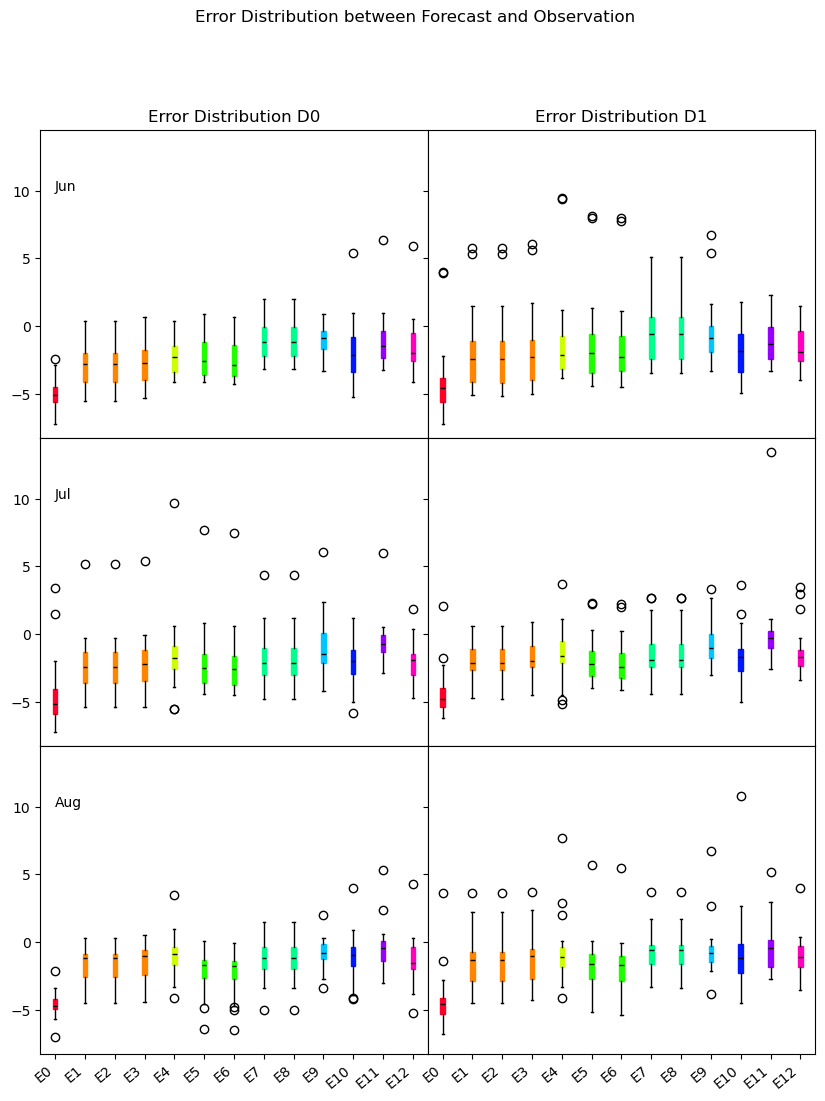

In [ ]:
list_months, list_years = [6,7,8], [2023]
plot_error_distrib_violin(list_months, list_years, var="TEMPERATURE/DRY-BULB TEMPERATURE")

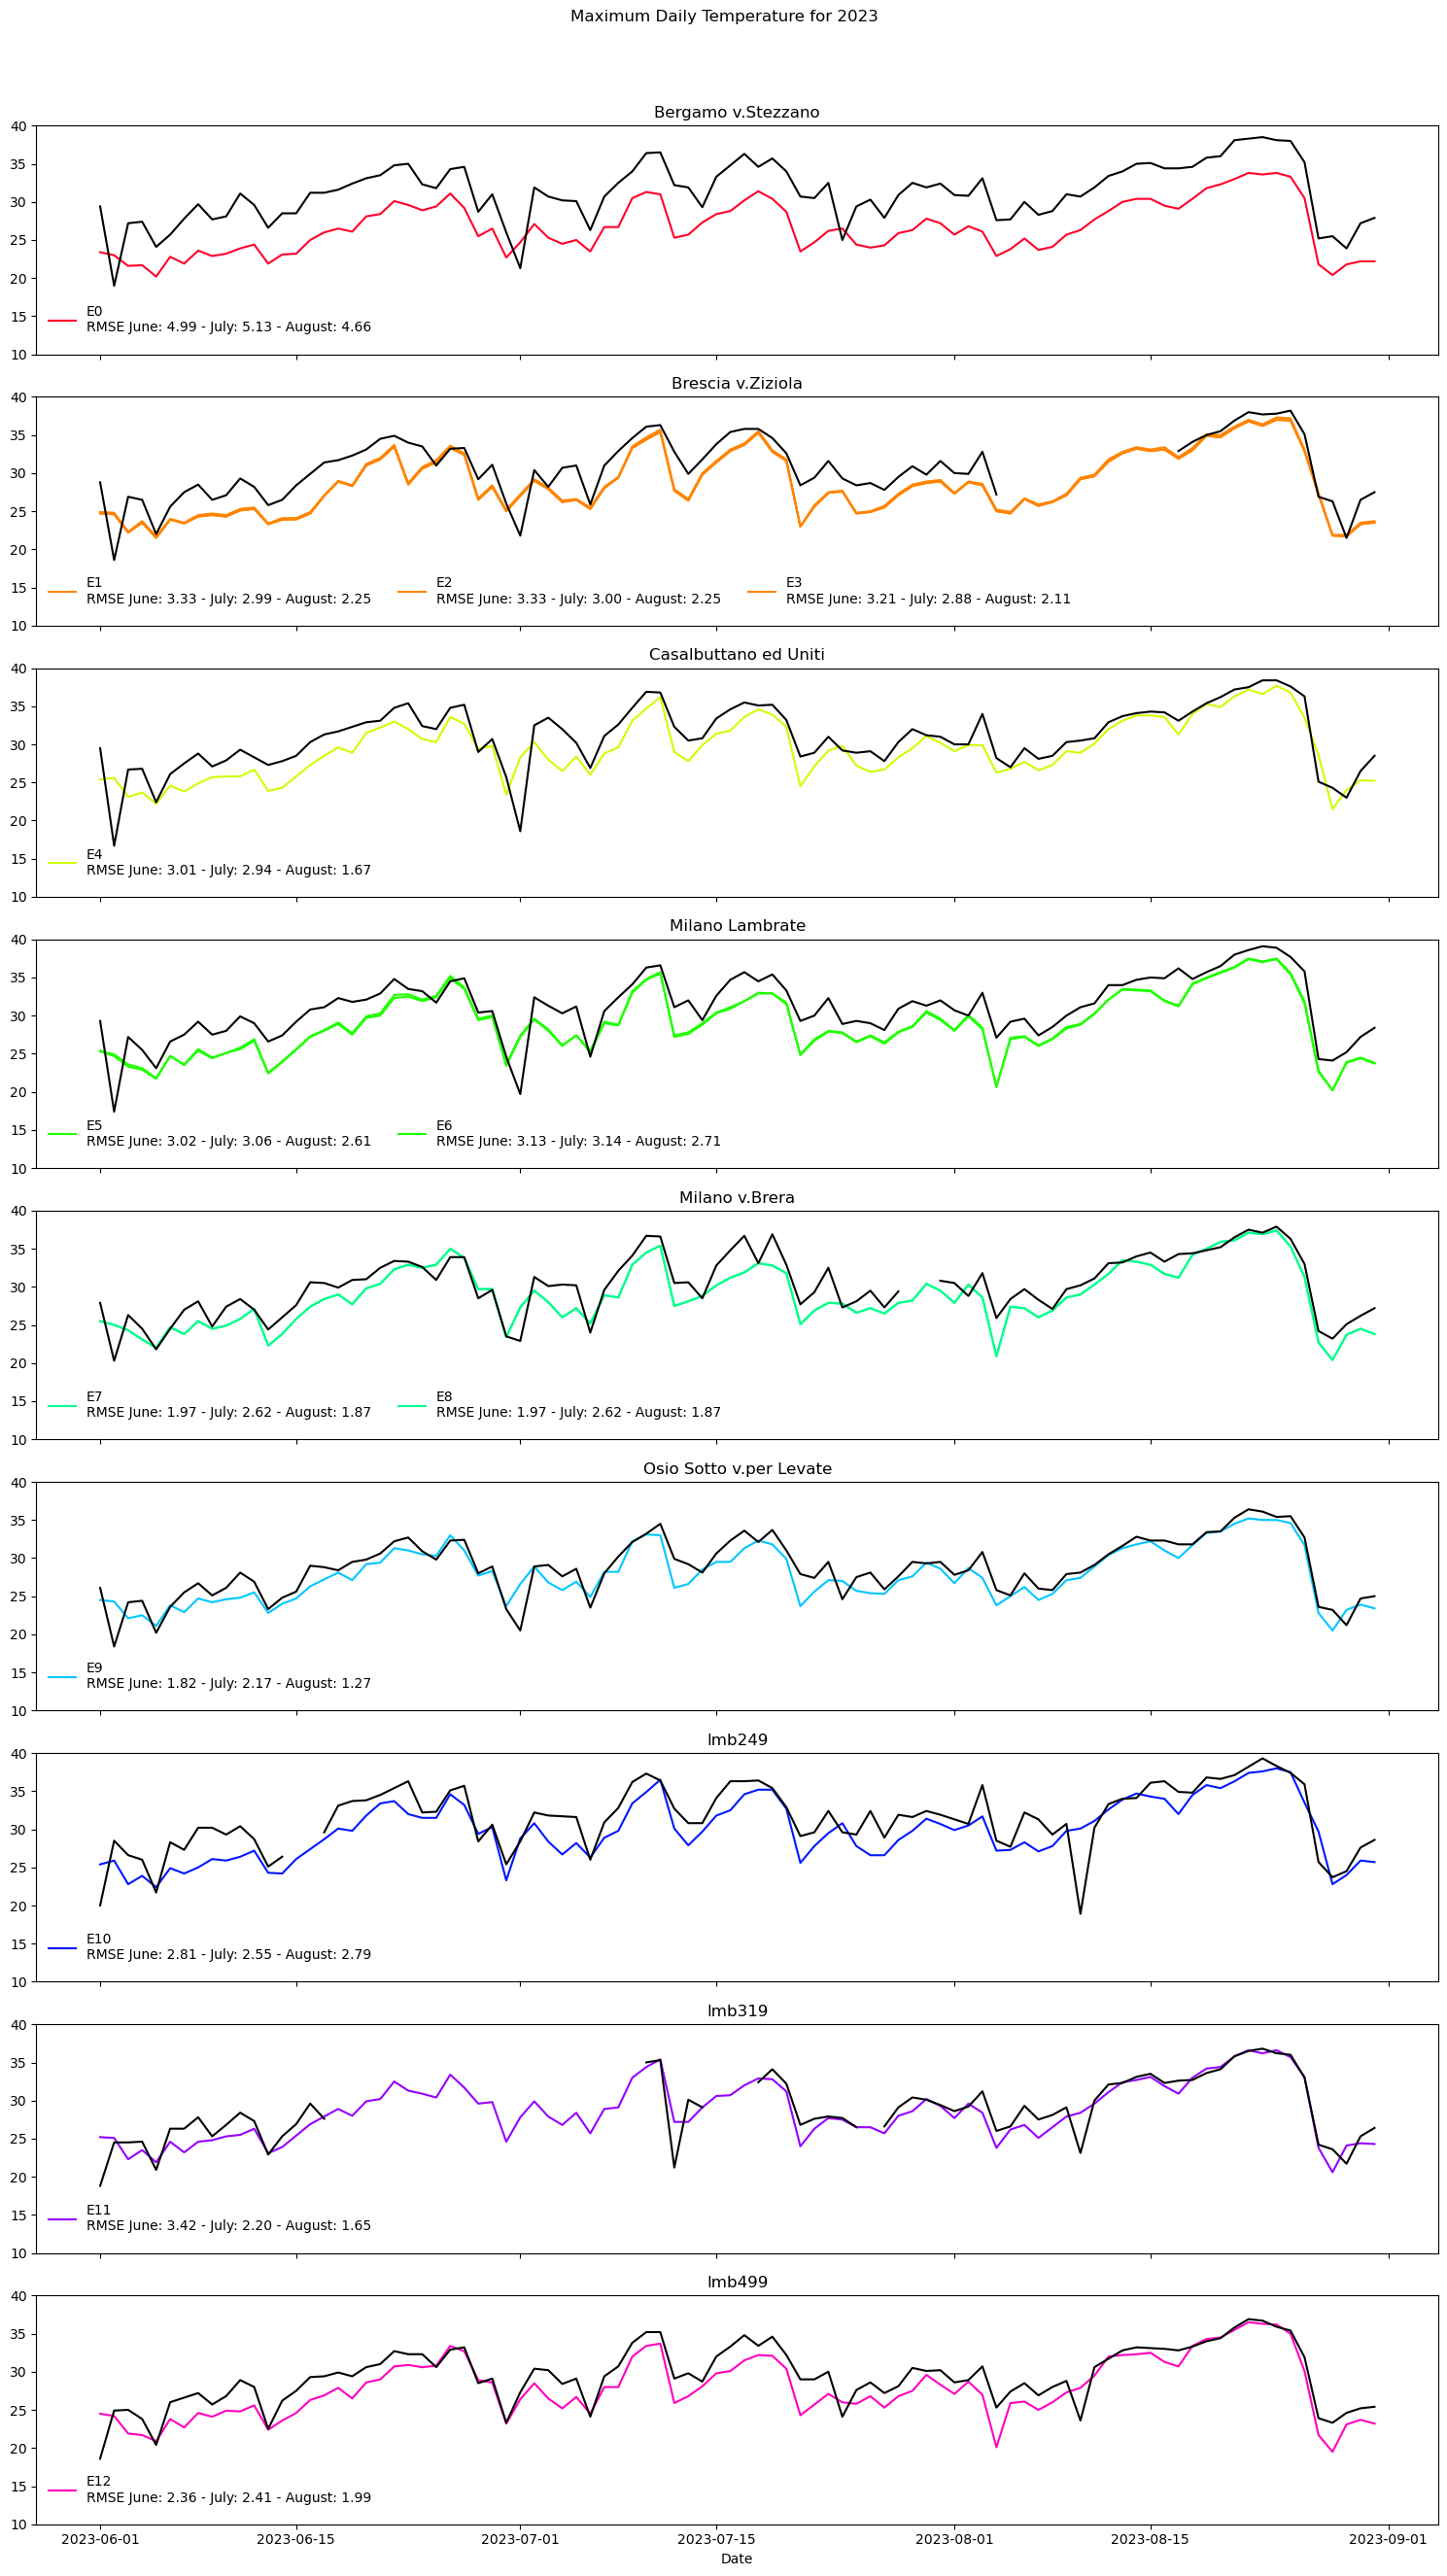

In [ ]:
def query_and_plot_max_temp(year, var="TEMPERATURE/DRY-BULB TEMPERATURE"):
    """
    Query the ECOP forecasts and Mistral observations for June-July-August for a chosen year.
    Create a figure with subplots for each station, plotting the timeseries of maximum daily temperature for observations and forecasts.
    Add the RMSE (error=forecast-observation) in a textbox for each month.
    """
    # Define the months and create a list of trade dates
    list_months = [6, 7, 8]
    list_trade_dates = [dt.datetime(year, month, day, 0, 0, 0, 0, pytz.UTC) for month in list_months for day in range(1, monthrange(year, month)[1] + 1)]
    list_date_str = [date.strftime('%Y-%m-%dT%H:%M:%S') for date in list_trade_dates]
    #list_trade_dates = np.array(list_date_str, dtype='datetime64[s]')

    list_stname = sorted(list(set(anagrafe['station_name'].values)))
    n = len(list_stname)
    colorz = plt.cm.gist_rainbow(np.linspace(0, 1, n))

    # Query ECOP forecasts
    ecop = query_ecop_ponctual([(lat, lon) for lat, lon in zip(anagrafe['lat_gridpoint'].values, anagrafe['lon_gridpoint'].values)], var='T_2M_C', list_forecast_date=list_date_str)
    dates_from_ecop = list(set(ecop['VALID_DATE'].to_list())) # datetime64[ns]
    dates_from_ecop.sort()

    # Query Mistral observations
    _, obs = query_mistral_ponctual(list(anagrafe['station_id'].values), var=var, dates=[d.strftime("%Y-%m-%dT%H:%M:%S") for d in dates_from_ecop])

    # Create figure with subplots for each station
    list_stname = sorted(list(set(anagrafe['station_name'].values)))
    n = len(list_stname)
    fig, axes = plt.subplots(n, 1, figsize=(15, 3 * n), sharex=True, sharey=True)

    # Calculate RMSE and plot timeseries
    for i, station in enumerate(list_stname):
        ax = axes[i]
        lat_station, lon_station = anagrafe['lat_station'][anagrafe['station_name'] == station].values[0], anagrafe['lon_station'][anagrafe['station_name'] == station].values[0]

        nf=0
        for id, lat_forecast, lon_forecast in zip(anagrafe.index[anagrafe['station_name'] == station].to_list(), anagrafe['lat_gridpoint'][anagrafe['station_name'] == station].to_list(), anagrafe['lon_gridpoint'][anagrafe['station_name'] == station].to_list()):
            
            max_obs = []
            max_fcst = []
            nf+=1
            
            for td in list_trade_dates:

                forecast_ecop_d0 = ecop[(ecop['LAT'] == lat_forecast) & (ecop['LON'] == lon_forecast) & (ecop['TRADE_DATE']==td) & (ecop['VALID_DATE'].isin([td + dt.timedelta(hours=n) for n in range(24)]))]
                dates_from_this_forecast = forecast_ecop_d0['VALID_DATE'].to_list()
                obs_slice = obs.loc[(obs['LATITUDE'] == lat_station) & (obs['LONGITUDE'] == lon_station) & (obs['REF_TIME'].isin([td + dt.timedelta(hours=n) for n in range(24)]))]
                
                if forecast_ecop['VALUE'].empty:
                    max_fcst.append(np.nan)
                else:
                    max_fcst.append(forecast_ecop_d0['VALUE'].max())

                if obs_slice['VALUE'].empty or obs_slice['VALUE'].max()<273:
                    max_obs.append(np.nan)

                else:
                    max_obs.append(obs_slice['VALUE'].max()-273.15)

            #print(id)
            #print(max_obs)
            #print(max_fcst)

            # Calculate RMSE for each month and forecast
            rmse_june = np.sqrt(np.nanmean((np.array(max_fcst[:30]) - np.array(max_obs[:30]))**2))
            rmse_july = np.sqrt(np.nanmean((np.array(max_fcst[30:61]) - np.array(max_obs[30:61]))**2))
            rmse_august = np.sqrt(np.nanmean((np.array(max_fcst[61:]) - np.array(max_obs[61:]))**2))

            # Add RMSE to label
            textstr = ' - '.join((
                f'RMSE June: {rmse_june:.2f}',
                f'July: {rmse_july:.2f}',
                f'August: {rmse_august:.2f}',
            ))

            # Plot timeseries
            ax.plot(list_trade_dates, max_fcst, label=f'{id}\n{textstr}', color=colorz[i])
        ax.plot(list_trade_dates, max_obs, color='k')

        ax.set_title(station)

        ax.set_ylim(10, 40)

        # legend
        ax.legend(ncol=nf+1, loc='center left', bbox_to_anchor=(.0, 0.15), frameon=False, labelspacing=3.)

    plt.xlabel('Date')
    plt.suptitle(f'Maximum Daily Temperature for {year}')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return None

# Call the function with the chosen year
query_and_plot_max_temp(year=2023)